# Brain Tumor Classifier using PyTorch

- classifies MRI scans as glioma, meningioma, pituitary, or no tumor  
- uses a small cnn with a few conv and dense layers  
- trains on 256x256 grayscale images from images/Training and images/Testing  
- tracks training and validation accuracy each epoch  
- includes a quick test function to predict any single image and show its confidence


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((256, 256)),
    transforms.ToTensor(), 
    transforms.Normalize((0.5,), (0.5,))
])


In [ ]:
train_dataset = datasets.ImageFolder(root="images/Training", transform=transform)
test_dataset = datasets.ImageFolder(root="images/Testing", transform=transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Classes:", train_dataset.classes)
print("Number of training samples:", len(train_dataset))
print("Number of testing samples:", len(test_dataset))


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of training samples: 5712
Number of testing samples: 1311


In [ ]:
class BrainTumorCNN(nn.Module):
    def __init__(self):
        super(BrainTumorCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 4)  # 4 output classes

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))

        x = x.view(-1, 64 * 32 * 32)  # flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [ ]:
# Hyperparameters
EPOCHS = 10
LR = 0.001
BATCH_SIZE = 32
EVAL_EVERY = 1

criterion = nn.CrossEntropyLoss()
model = BrainTumorCNN()
optimizer = optim.Adam(model.parameters(), lr=LR)


In [ ]:
def train_brain_tumor_model(model, train_loader, test_loader, criterion, optimizer, epochs=EPOCHS):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        model.train()
        total_loss, correct = 0, 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()

        avg_train_loss = total_loss / len(train_loader.dataset)
        train_acc = 100 * correct / len(train_loader.dataset)

        # Evaluate
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()

        avg_val_loss = val_loss / len(test_loader.dataset)
        val_acc = 100 * val_correct / len(test_loader.dataset)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    return train_losses, val_losses, train_accs, val_accs


In [ ]:
# Train Model(may take a while) - adjust hyperparameters first - see above
train_losses, val_losses, train_accs, val_accs = train_brain_tumor_model(
    model, train_loader, test_loader, criterion, optimizer, epochs=EPOCHS
)

torch.save(model.state_dict(), "brain_tumor_cnn.pth")


Epoch 1/20 | Train Loss: 0.5880 | Train Acc: 77.01% | Val Loss: 0.4673 | Val Acc: 82.84%
Epoch 2/20 | Train Loss: 0.2942 | Train Acc: 89.65% | Val Loss: 0.2989 | Val Acc: 89.40%
Epoch 3/20 | Train Loss: 0.1599 | Train Acc: 94.19% | Val Loss: 0.2222 | Val Acc: 91.08%
Epoch 4/20 | Train Loss: 0.0888 | Train Acc: 96.92% | Val Loss: 0.2124 | Val Acc: 92.68%
Epoch 5/20 | Train Loss: 0.0495 | Train Acc: 98.32% | Val Loss: 0.1917 | Val Acc: 94.43%
Epoch 6/20 | Train Loss: 0.0229 | Train Acc: 99.35% | Val Loss: 0.2102 | Val Acc: 94.43%
Epoch 7/20 | Train Loss: 0.0321 | Train Acc: 98.93% | Val Loss: 0.2038 | Val Acc: 94.36%
Epoch 8/20 | Train Loss: 0.0516 | Train Acc: 98.69% | Val Loss: 0.1858 | Val Acc: 95.35%
Epoch 9/20 | Train Loss: 0.0299 | Train Acc: 99.05% | Val Loss: 0.1472 | Val Acc: 95.96%
Epoch 10/20 | Train Loss: 0.0043 | Train Acc: 99.91% | Val Loss: 0.2198 | Val Acc: 95.65%
Epoch 11/20 | Train Loss: 0.0010 | Train Acc: 99.98% | Val Loss: 0.1827 | Val Acc: 96.57%
Epoch 12/20 | Train

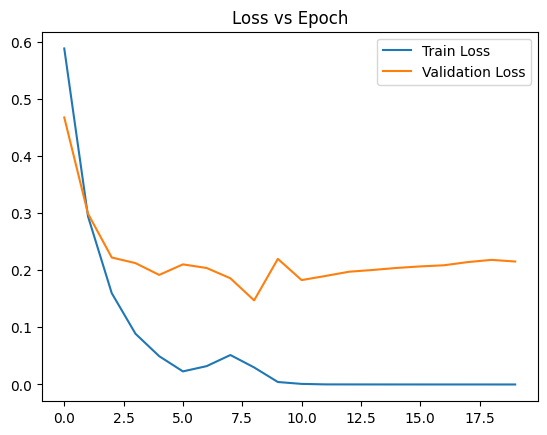

In [8]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.title('Loss vs Epoch')
plt.show()


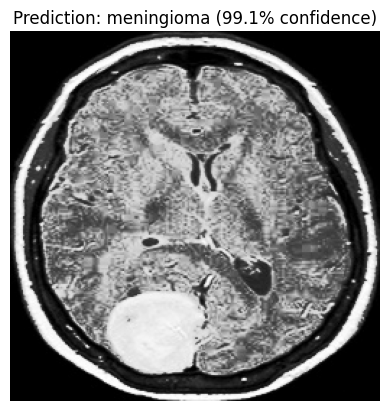

Prediction for '/Users/mtsampt/Documents/CS-4641-Group-130/src/dataset/Testing/meningioma/Te-me_0010.jpg': meningioma
Confidence: 99.06%

Class probabilities:
  glioma      : 0.00%
  meningioma  : 99.06%
  notumor     : 0.94%
  pituitary   : 0.00%


('meningioma', 99.05530214309692)

In [16]:
# Single Image Prediction
from PIL import Image
import torch.nn.functional as F

def predict_single_image(model, image_path: str, transform, class_names, show_all_probs=True):

    image = Image.open(image_path).convert("L")
    image_tensor = transform(image).unsqueeze(0)

    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model.to(device)
    image_tensor = image_tensor.to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probs = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)

    predicted_class = class_names[predicted.item()]
    confidence_pct = confidence.item() * 100

    plt.imshow(image, cmap="gray")
    plt.title(f"Prediction: {predicted_class} ({confidence_pct:.1f}% confidence)")
    plt.axis("off")
    plt.show()

    print(f"Prediction for '{image_path}': {predicted_class}")
    print(f"Confidence: {confidence_pct:.2f}%")

    if show_all_probs:
        print("\nClass probabilities:")
        for i, cls in enumerate(class_names):
            print(f"  {cls:12s}: {probs[0, i].item() * 100:.2f}%")

    return predicted_class, confidence_pct

# Copy the path of a jpg in the testing data folder and paste it below to test individual images.
test_image_path = "/Users/mtsampt/Documents/CS-4641-Group-130/src/dataset/Testing/meningioma/Te-me_0010.jpg"
predict_single_image(model, test_image_path, transform, train_dataset.classes)

